# Configuracoes do ambiente

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from scipy import stats

warnings.filterwarnings('ignore')



In [2]:
# Layout de visualizacao grafica
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)


In [3]:
# 1. Dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

### Dicionário de Dados - Telco Customer Churn

| Variável | Tipo de Dado (Pandas) | Descrição |
| :--- | :--- | :--- |
| **customerID** | `object` (String) | ID único de identificação do cliente. |
| **gender** | `object` (String) | Gênero do cliente (Male, Female). |
| **SeniorCitizen** | `int64` (Inteiro) | Indica se o cliente é um idoso (1) ou não (0). |
| **Partner** | `object` (String) | Indica se o cliente tem um parceiro/cônjuge (Yes, No). |
| **Dependents** | `object` (String) | Indica se o cliente tem dependentes, como filhos (Yes, No). |
| **tenure** | `int64` (Inteiro) | Número de meses que o cliente permaneceu na empresa. |
| **PhoneService** | `object` (String) | Indica se o cliente tem serviço de telefone (Yes, No). |
| **MultipleLines** | `object` (String) | Indica se o cliente tem múltiplas linhas telefônicas (Yes, No, No phone service). |
| **InternetService** | `object` (String) | Provedor de serviço de internet do cliente (DSL, Fiber optic, No). |
| **OnlineSecurity** | `object` (String) | Indica se o cliente tem serviço de segurança online (Yes, No, No internet service). |
| **OnlineBackup** | `object` (String) | Indica se o cliente tem serviço de backup online (Yes, No, No internet service). |
| **DeviceProtection** | `object` (String) | Indica se o cliente tem serviço de proteção de dispositivo (Yes, No, No internet service). |
| **TechSupport** | `object` (String) | Indica se o cliente tem suporte técnico (Yes, No, No internet service). |
| **StreamingTV** | `object` (String) | Indica se o cliente tem serviço de streaming de TV (Yes, No, No internet service). |
| **StreamingMovies** | `object` (String) | Indica se o cliente tem serviço de streaming de filmes (Yes, No, No internet service). |
| **Contract** | `object` (String) | O termo de contrato do cliente (Month-to-month, One year, Two year). |
| **PaperlessBilling** | `object` (String) | Indica se o cliente optou por faturamento sem papel/fatura digital (Yes, No). |
| **PaymentMethod** | `object` (String) | O método de pagamento do cliente (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic)). |
| **MonthlyCharges** | `float64` (Decimal) | O valor cobrado do cliente mensalmente. |
| **TotalCharges** | `object` / `float64` | O valor total cobrado do cliente ao longo do tempo. |
| **Churn** | `object` (String) | **Variável Alvo (Target):** Indica se o cliente cancelou o serviço no último mês (Yes, No). |

> ⚠️ **Nota de Atenção:** A coluna `TotalCharges` possui strings vazias (`" "`) para clientes com `tenure == 0`. É necessário tratá-los e convertê-los usando `pd.to_numeric(df['TotalCharges'], errors='coerce')`.

In [4]:
df.columns = df.columns.str.strip()  # Remove espaços em branco dos nomes das colunas
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')  # Converte a coluna 'TotalCharges' para numérica, tratando erros como NaN
# Verificar se a conversão foi bem-sucedida
print(df['TotalCharges'].dtype)  # Deve mostrar 'float64' ou 'int64'


float64


In [5]:
print(f"Shape dos dados: {df.shape}")
print(f"\nPrimeiras linhas do dataset:")
df.head(10)

Shape dos dados: (7043, 21)

Primeiras linhas do dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


# Analise de dados faltantes

In [6]:
df.isnull().sum()/len(df) * 100

customerID          0.000000
gender              0.000000
SeniorCitizen       0.000000
Partner             0.000000
Dependents          0.000000
tenure              0.000000
PhoneService        0.000000
MultipleLines       0.000000
InternetService     0.000000
OnlineSecurity      0.000000
OnlineBackup        0.000000
DeviceProtection    0.000000
TechSupport         0.000000
StreamingTV         0.000000
StreamingMovies     0.000000
Contract            0.000000
PaperlessBilling    0.000000
PaymentMethod       0.000000
MonthlyCharges      0.000000
TotalCharges        0.156183
Churn               0.000000
dtype: float64

In [7]:
# OBS: Os NA's de totalcharges possuem um padrão: elas possuem a variável tenure (tempo de permanência) igual a 0. Ou seja, são clientes novatos, que acabaram de assinar o contrato e ainda não completaram o primeiro mês (nem pagaram a primeira fatura completa). O campo de cobrança total está vazio não por um erro de sistema, mas porque não houve tempo para acumular cobranças. Imputarei o valor 0 para esses casos, pois é o mais lógico, dado que eles não tiveram tempo de gerar cobranças!!!!
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [8]:
# Separando as variáveis contínuas (excluindo a SeniorCitizen que é categórica "disfarçada")
variaveis_continuas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
variaveis_continuas.remove('SeniorCitizen')

# 2. Pegando as variáveis categóricas (textos + a SeniorCitizen)
variaveis_categoricas = df.select_dtypes(include=['object']).columns.tolist()
variaveis_categoricas.append('SeniorCitizen')

# Mostrando o resultado
print("Contínuas:", variaveis_continuas)
print("Categóricas:", variaveis_categoricas)

Contínuas: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categóricas: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn', 'SeniorCitizen']


In [9]:
# Informações gerais sobre o dataset
print("=== INFORMAÇÕES GERAIS DO DATASET ===\n")
print(df.info())

print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
df[variaveis_continuas].describe().round(2)

=== INFORMAÇÕES GERAIS DO DATASET ===

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilli

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


# Analise da variavell target


In [10]:
# Renomeando a coluna 'churn' para 'target'
df.rename(columns={'churn': 'target'}, inplace=True)

In [11]:
df.Churn.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
# Renomear variável `Churn` para `target`
df.rename(columns={'Churn': 'target'}, inplace=True)

# Mapear os valores 'No' para 0 e 'Yes' para 1 na coluna 'target'
df['target'] = df['target'].map({'No': 0, 'Yes': 1})


print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100

print("Contagem:")
print(target_counts)
print("\nPercentual:")

=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

Contagem:
target
0    5174
1    1869
Name: count, dtype: int64

Percentual:


No (0): 73.46%
Yes (1): 26.54%


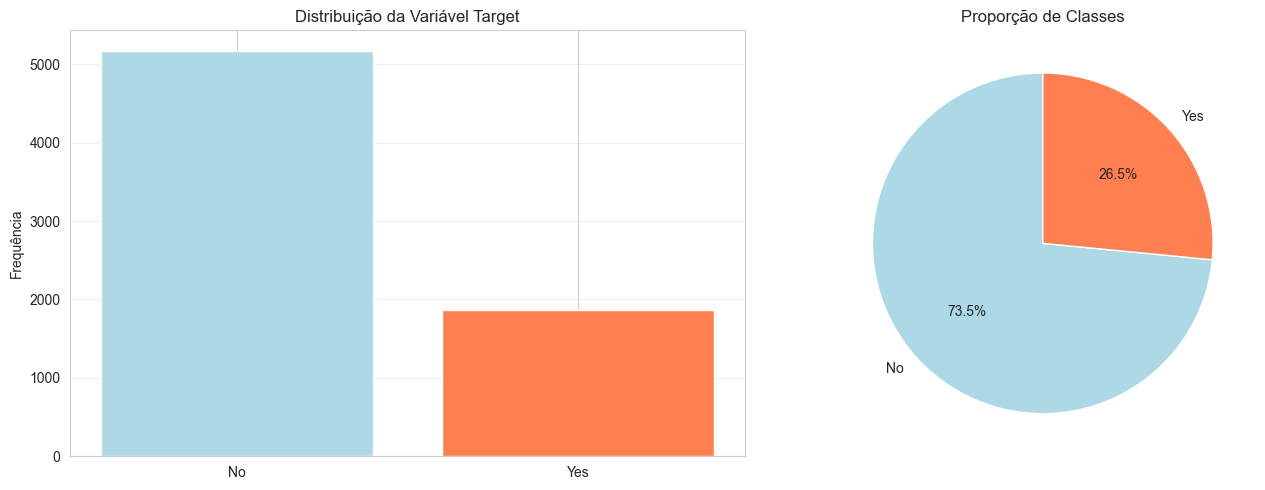


Ratio de balanceamento: 0.36
⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.


In [13]:
for idx, pct in target_percentages.items():
    label = "No" if idx == 0 else "Yes"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(['No', 'Yes'], target_counts.values, color=['lightblue', 'coral'])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Target')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(target_counts.values, labels=['No', 'Yes'], 
            autopct='%1.1f%%', colors=['lightblue', 'coral'], startangle=90)
axes[1].set_title('Proporção de Classes')

plt.tight_layout()
plt.show()

# Verificar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.")
else:
    print("✓ Dataset razoavelmente balanceado.")

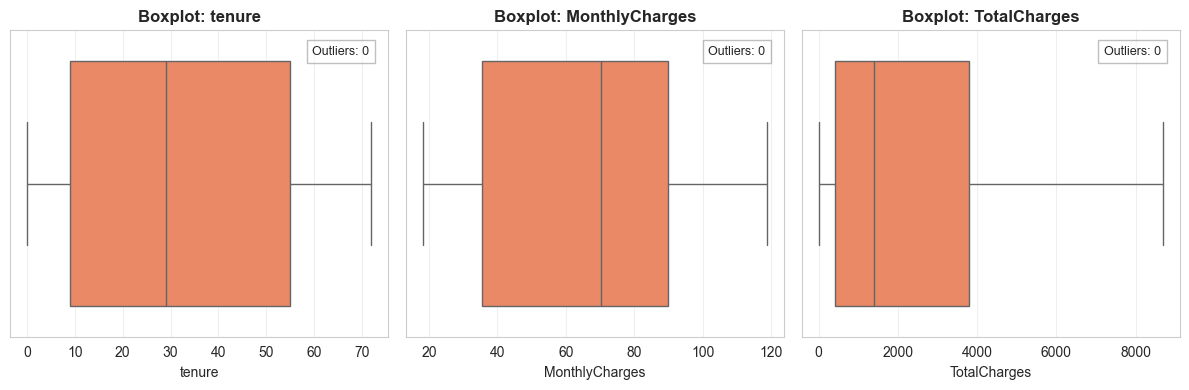

In [14]:
n = len(variaveis_continuas)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(variaveis_continuas):
    sns.boxplot(x=df[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}', 
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


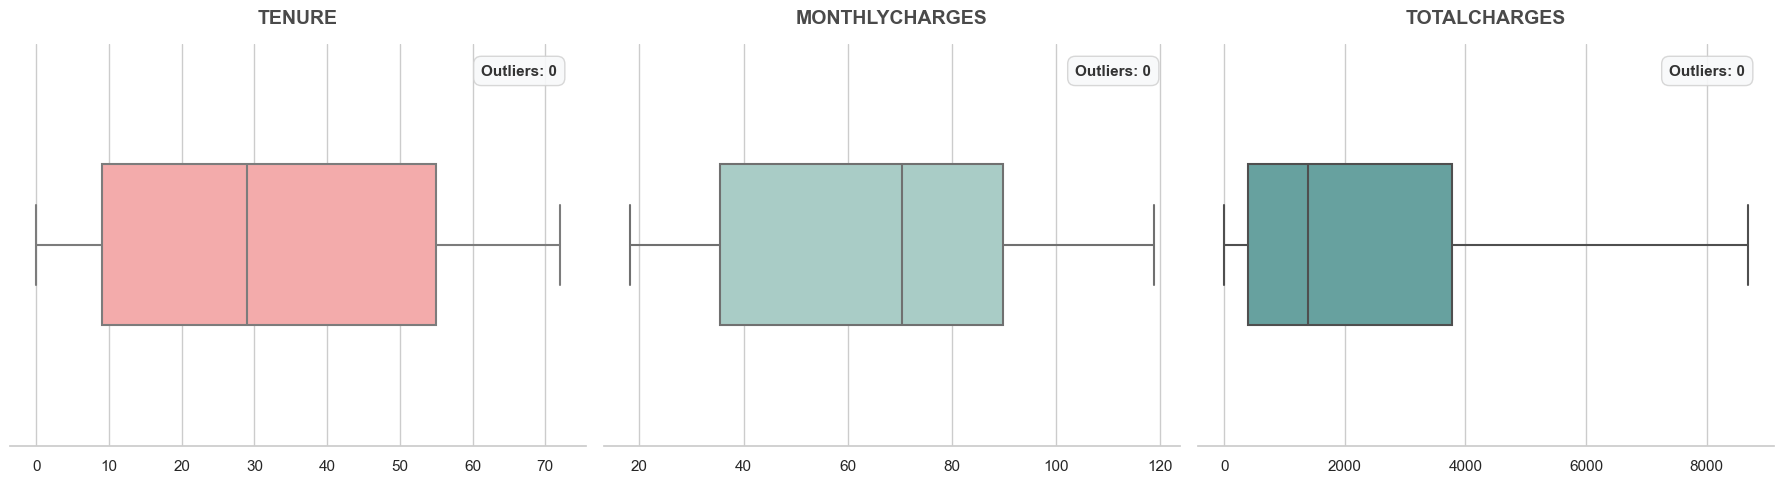

In [15]:
# Avaliando os outliers com o método do IQR (Interquartile Range)

# Lista das suas variáveis contínuas
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# 1. Configurando um tema moderno do Seaborn (fundo branco com linhas de grade suaves)
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False})

# 2. Criando a figura e os subplots (1 linha, 3 colunas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3. Escolhendo uma paleta de cores moderna (você pode trocar por 'Set2', 'husl', etc.)
cores = ['#FF9F9F', '#A3D2CA', '#5EAAA8']

for i, col in enumerate(cols):
    
    # --- CÓDIGO DE CÁLCULO DE OUTLIERS ---
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outlier_count = ((df[col] < limite_inferior) | (df[col] > limite_superior)).sum()
    # ---------------------------------------------------

    # 4. Desenhando o Boxplot 
    sns.boxplot(
        x=df[col], 
        ax=axes[i], 
        color=cores[i], 
        width=0.4,          # Deixa a caixa mais fina e elegante
        linewidth=1.5,      # Linhas mais bem definidas
        flierprops={"marker": "o", "markersize": 6, "markerfacecolor": "#e74c3c", "alpha": 0.6} # Destaca outliers em vermelho se existirem
    )
    
    # 5. Formatando Títulos e Eixos
    axes[i].set_title(col.upper(), fontsize=14, pad=15, fontweight='bold', color='#4a4a4a')
    axes[i].set_xlabel('') # Remove o nome do eixo X para ficar mais limpo
    
    # 6. Anotação de Outliers com visual de "Badge" (Etiqueta)
    axes[i].text(
        0.95, 0.95, 
        f'Outliers: {outlier_count}', 
        transform=axes[i].transAxes, 
        fontsize=11,
        fontweight='bold',
        color='#333333',
        ha='right', va='top', 
        bbox=dict(boxstyle="round,pad=0.5", edgecolor='#d3d3d3', facecolor='#f8f9fa', alpha=0.9)
    )

# Ajusta o espaçamento para não sobrepor nada
plt.tight_layout()
plt.show()

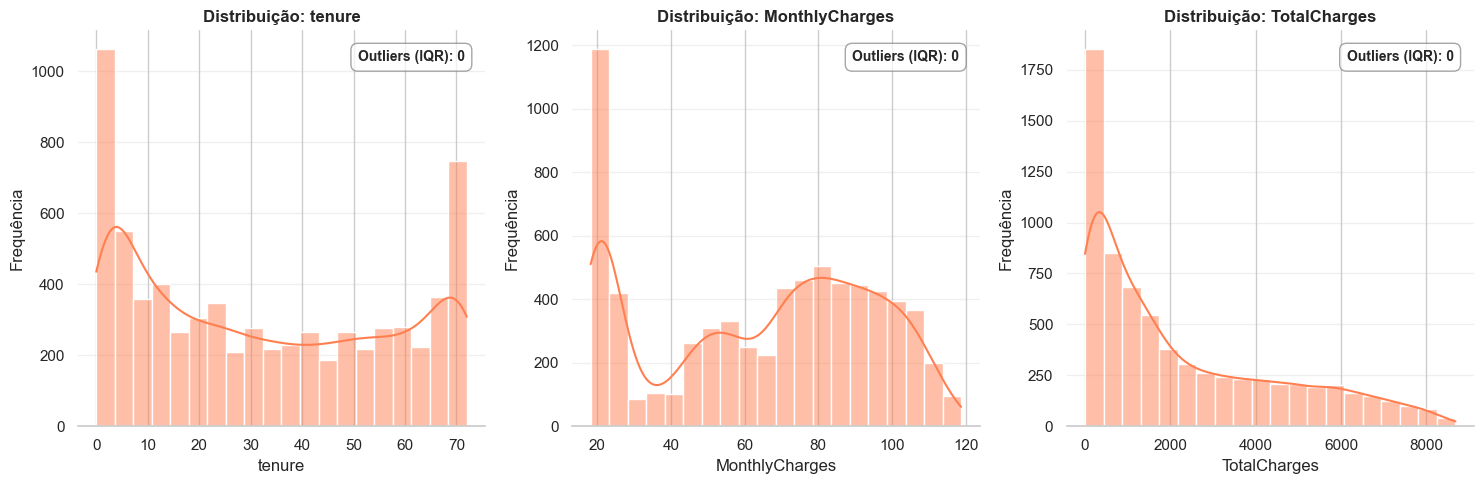

In [16]:
# Avaliando os outliers com o método do IQR (Interquartile Range) - Versão Completa
# 1. Definição das colunas (mesma lógica anterior)
#numeric_cols = df.select_dtypes(include=[np.number]).columns
#numeric_cols = numeric_cols.drop(['id', 'target'], errors='ignore')

n = len(variaveis_continuas)
ncols = 3
nrows = int(np.ceil(n / ncols))

# 2. Configuração da Figura
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = axes.ravel()

for idx, col in enumerate(variaveis_continuas):
    # Cálculo de Outliers (Regra do IQR)
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    outlier_count = ((df[col] < limite_inf) | (df[col] > limite_sup)).sum()

    # Criando o Histograma
    sns.histplot(df[col], ax=axes[idx], color='coral', kde=True, bins=20)
    
    # Estilização (Mantendo o seu padrão)
    axes[idx].set_title(f'Distribuição: {col}', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequência')
    axes[idx].grid(axis='y', alpha=0.3)

    # Adicionando a caixa com a quantidade de outliers
    axes[idx].text(0.95, 0.95, f'Outliers (IQR): {outlier_count}', 
                   transform=axes[idx].transAxes, fontsize=10, fontweight='bold',
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round,pad=0.5'))

# Remover eixos vazios caso o número de colunas não seja múltiplo de 3
for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

# Avaliando anomalias

In [17]:
print("=== ANÁLISE DE ANOMALIAS E REGRAS DE NEGÓCIO (TELCO CHURN) ===\n")

anomalies = []

# 1. Tenure (Tempo de casa) - Não pode ser negativo 
tenure_anomalies = df[df['tenure'] < 0]
if len(tenure_anomalies) > 0:
    anomalies.append(f"Tenure negativo: {len(tenure_anomalies)} casos")
    print(f"⚠️ Tempo de casa negativo detectado: {len(tenure_anomalies)} casos")

# 2. MonthlyCharges (Mensalidade) - Não pode ser negativa ou zero (assumindo que não há plano grátis)
mc_anomalies = df[df['MonthlyCharges'] <= 0]
if len(mc_anomalies) > 0:
    anomalies.append(f"Mensalidade zerada ou negativa: {len(mc_anomalies)} casos")
    print(f"⚠️ Mensalidade inválida detectada: {len(mc_anomalies)} casos")

# 3. TotalCharges - Não pode ser negativo (Assumindo que já foi convertido para numérico)
if pd.api.types.is_numeric_dtype(df['TotalCharges']):
    tc_anomalies = df[df['TotalCharges'] < 0]
    if len(tc_anomalies) > 0:
        anomalies.append(f"TotalCharges negativo: {len(tc_anomalies)} casos")
        print(f"⚠️ Cobrança total negativa detectada: {len(tc_anomalies)} casos")

# 4. Verificações de consistência lógica 
# 4.1. Sem serviço de telefone, mas com múltiplas linhas ativas?
phone_logic_error = df[(df['PhoneService'] == 'No') & (df['MultipleLines'] != 'No phone service')]
if len(phone_logic_error) > 0:
    anomalies.append(f"Conflito Lógico - Telefone: {len(phone_logic_error)} casos")
    print(f"⚠️ Clientes sem telefone, mas marcados com múltiplas linhas: {len(phone_logic_error)} casos")

# 4.2. Sem internet, mas com serviços dependentes ativos?
internet_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in internet_cols:
    net_logic_error = df[(df['InternetService'] == 'No') & (df[col] != 'No internet service')]
    if len(net_logic_error) > 0:
        anomalies.append(f"Conflito Lógico - {col}: {len(net_logic_error)} casos")
        print(f"⚠️ Clientes sem internet, mas com {col} ativo: {len(net_logic_error)} casos")

categorical_checks = {
    'gender': ['Female', 'Male'],
    'SeniorCitizen': [0, 1],
    'Partner': ['Yes', 'No'],
    'Dependents': ['Yes', 'No'],
    'Contract': ['Month-to-month', 'One year', 'Two year'],
    'PaymentMethod': ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'],
    'Churn': [0, 1]  # <--- Ajustado para 0 e 1 conforme a sua base
}

for col, valid_values in categorical_checks.items():
    if col in df.columns:
        invalid = df[~df[col].isin(valid_values) & df[col].notna()]
        if len(invalid) > 0:
            anomalies.append(f"{col}: {len(invalid)} valores inválidos")
            print(f"⚠️ {col}: {len(invalid)} valores fora do domínio esperado {valid_values}")

# Resultados Finais
if len(anomalies) == 0:
    print("✓ Nenhuma anomalia lógica ou de domínio detectada! Base consistente.")
else:
    print(f"\n📊 Total de tipos de anomalias detectadas: {len(anomalies)}")

# 6. Verificar duplicados
if 'customerID' in df.columns:
    id_duplicates = df['customerID'].duplicated().sum()
    print(f"\n=== DUPLICADOS ===")
    print(f"IDs de clientes duplicados: {id_duplicates}")
    if id_duplicates > 0:
        print("⚠️ ALERTA: Existem IDs de clientes repetidos. É necessário remover as duplicatas.")
else:
    duplicates = df.duplicated().sum()
    print(f"\n=== DUPLICADOS ===")
    print(f"Linhas inteiras duplicadas: {duplicates}")
    if duplicates > 0:
        print("⚠️ Considere remover ou investigar registros duplicados")

=== ANÁLISE DE ANOMALIAS E REGRAS DE NEGÓCIO (TELCO CHURN) ===

✓ Nenhuma anomalia lógica ou de domínio detectada! Base consistente.

=== DUPLICADOS ===
IDs de clientes duplicados: 0


=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===

        Coluna  Skewness  Kurtosis         Interpretação
        tenure     0.240    -1.387                Normal
MonthlyCharges    -0.221    -1.257                Normal
  TotalCharges     0.963    -0.229 Assimétrica à direita


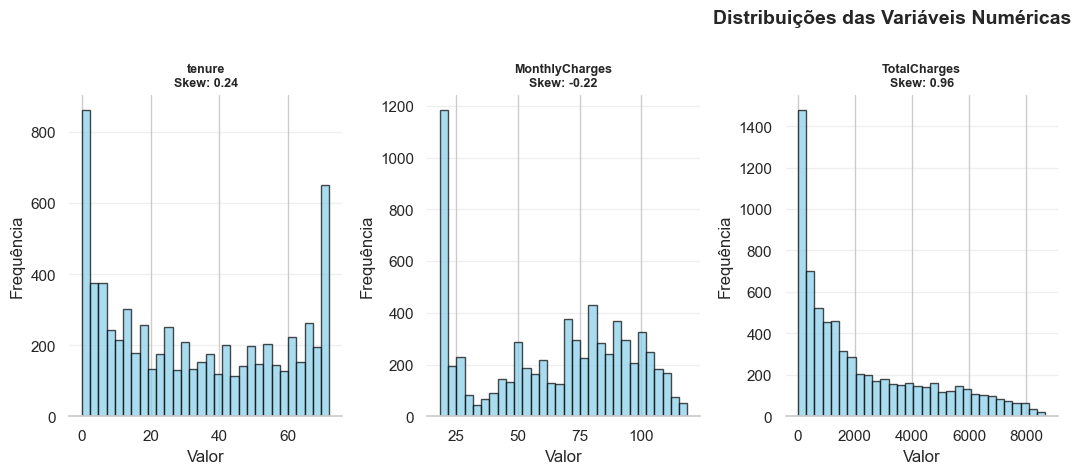

In [18]:
# Análise de distribuições
print("=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===\n")

distribution_stats = []
for col in variaveis_continuas:
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()
    distribution_stats.append({
        'Coluna': col,
        'Skewness': round(skewness, 3),
        'Kurtosis': round(kurtosis, 3),
        'Interpretação': 'Normal' if abs(skewness) < 0.5 else ('Assimétrica à direita' if skewness > 0 else 'Assimétrica à esquerda')
    })

dist_df = pd.DataFrame(distribution_stats)
print(dist_df.to_string(index=False))

# Visualizar distribuições
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(variaveis_continuas):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col}\nSkew: {df[col].skew():.2f}', fontsize=9, fontweight='bold')
        axes[idx].set_xlabel('Valor')
        axes[idx].set_ylabel('Frequência')
        axes[idx].grid(axis='y', alpha=0.3)

# Remover subplots vazios
for idx in range(len(variaveis_continuas), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribuições das Variáveis Numéricas', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Analise de correlação

# ATENCAO

A variável TotalCharges tem alta correlacao por um motivo especifico: ela se relaciona com o tempo de casa (Tenure) pela sua mensalidade, ou seja, essas variaveis falam praticamente a mesma coisa para o modelo.
Note que se mantermos ambas juntas e usarmos algoritmos mais sensíveis À multicolinearidade (tal como a Regressao Logistica) o modelo irá se confundir em relação ao impacto, e inflará a variÂncia, comprometendo a interpretabilidade dos resultados.+

## *Dado isso, optamos por remover o TotalCharges*


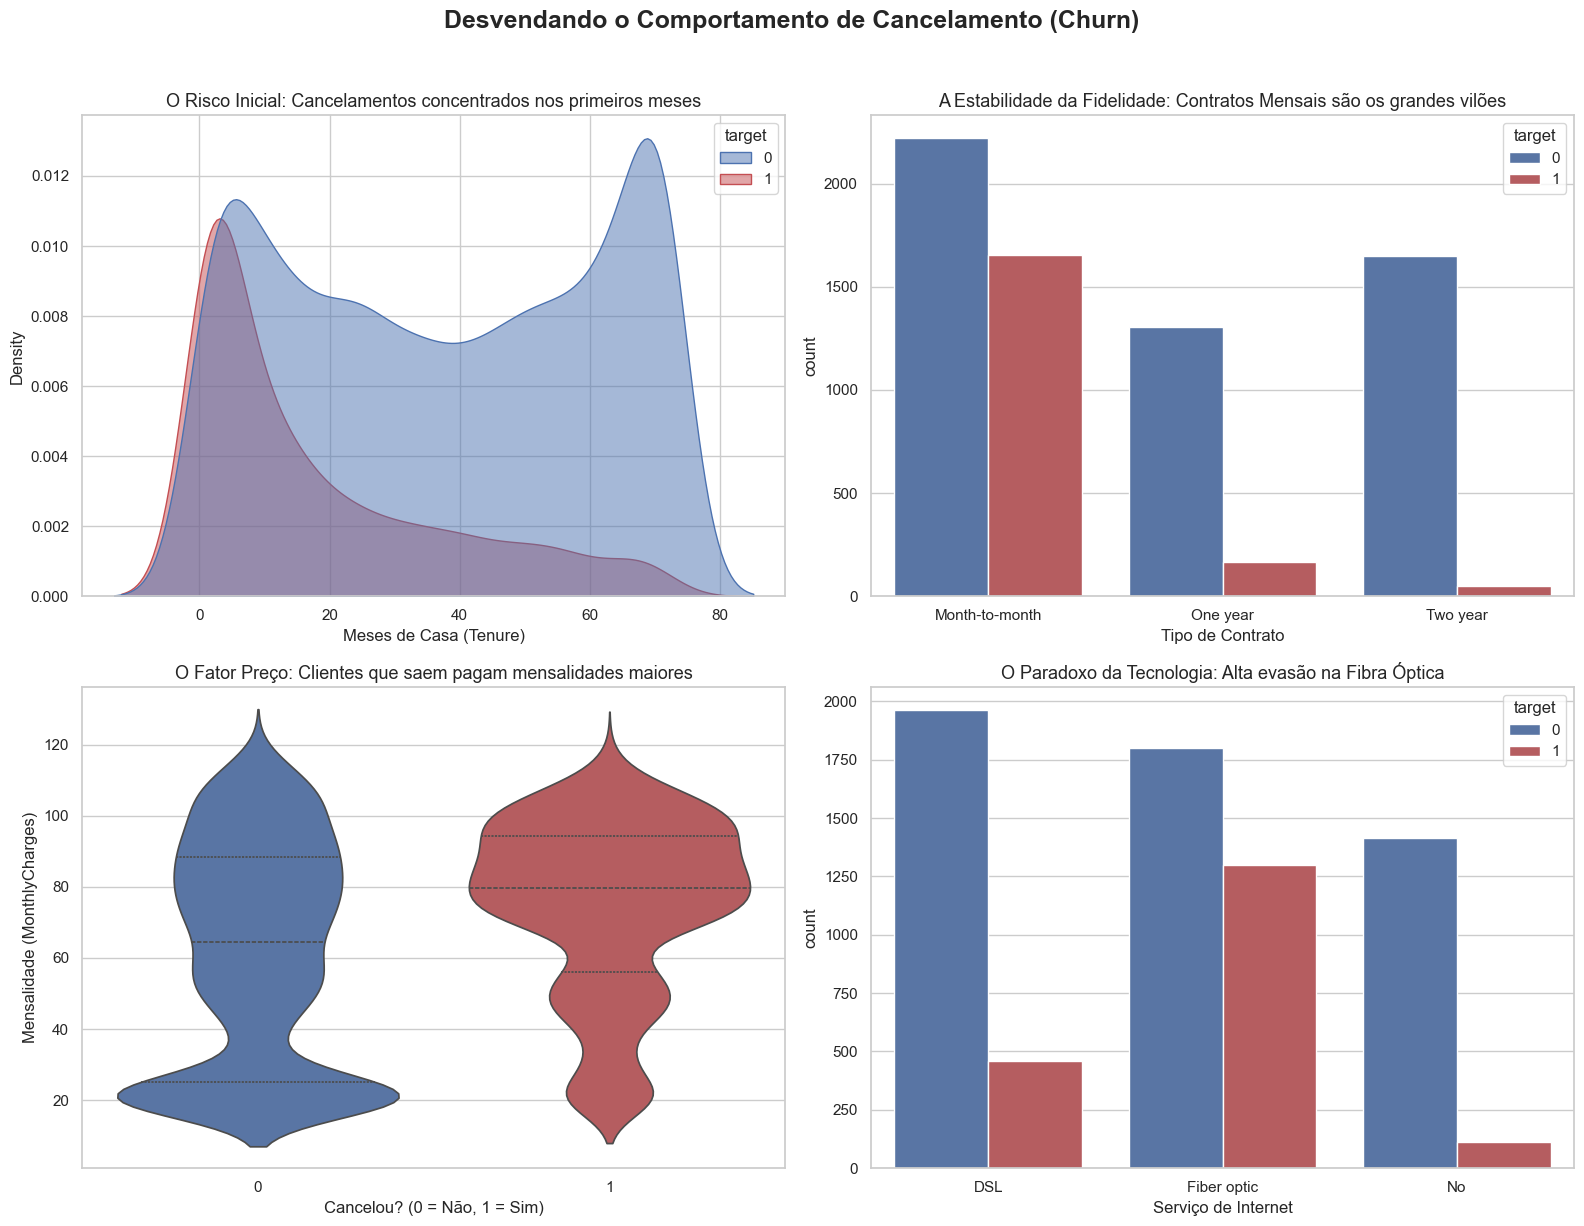

In [19]:
# Para entender melhor o comportamento do churn, vamos criar gráficos que mostrem as relações entre a variável target (churn) e outras variáveis importantes. Vou criar 4 gráficos principais:

# Configuração de estilo e cores (Mapeando tanto int quanto string para evitar conflitos do Seaborn)
sns.set_theme(style="whitegrid")
cores_churn = {0: '#4C72B0', 1: '#C44E52', '0': '#4C72B0', '1': '#C44E52'} 

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Desvendando o Comportamento de Cancelamento (Churn)', fontsize=18, fontweight='bold', y=1.02)

# 1. KDE Plot: Distribuição de Cancelamento pelo Tempo de Casa (Tenure)
sns.kdeplot(data=df, x='tenure', hue='target', fill=True, palette=cores_churn, ax=axes[0,0], alpha=0.5)
axes[0,0].set_title('O Risco Inicial: Cancelamentos concentrados nos primeiros meses', fontsize=13)
axes[0,0].set_xlabel('Meses de Casa (Tenure)')

# 2. Countplot: A Armadilha dos Contratos Mensais
sns.countplot(data=df, x='Contract', hue='target', palette=cores_churn, ax=axes[0,1])
axes[0,1].set_title('A Estabilidade da Fidelidade: Contratos Mensais são os grandes vilões', fontsize=13)
axes[0,1].set_xlabel('Tipo de Contrato')

# 3. Boxplot/Violin: Mensalidade vs Churn
sns.violinplot(data=df, x='target', y='MonthlyCharges', palette=cores_churn, ax=axes[1,0], inner="quartile")
axes[1,0].set_title('O Fator Preço: Clientes que saem pagam mensalidades maiores', fontsize=13)
axes[1,0].set_xlabel('Cancelou? (0 = Não, 1 = Sim)')
axes[1,0].set_ylabel('Mensalidade (MonthlyCharges)')

# 4. Countplot: O Paradoxo da Fibra Óptica
sns.countplot(data=df, x='InternetService', hue='target', palette=cores_churn, ax=axes[1,1])
axes[1,1].set_title('O Paradoxo da Tecnologia: Alta evasão na Fibra Óptica', fontsize=13)
axes[1,1].set_xlabel('Serviço de Internet')

plt.tight_layout()
plt.show()

# Codificacao de Variaveis Categoricas (One - hot encoding)

**Passos:**
- Identifique as colunas categóricas relevantes (ex.: `sex`, `cp`, `restecg`, `slope`, `thal`, `dataset`).
- Aplique o `pd.get_dummies()` para criar as variáveis dummies.
- Evite a duplicidade de informação removendo uma categoria de cada variável (drop_first=True), se necessário.

**Observações:**
- O One-hot Encoding aumenta o número de colunas, mas permite que modelos interpretem corretamente as categorias.
- Após a codificação, utilize o novo dataframe (`df_encoded`) para as etapas de modelagem.

In [20]:
# 1. Lista com todas as variáveis categóricas reais da base Telco Churn
# Nota: 'SeniorCitizen' e 'target' ficaram de fora porque você já os transformou em 0 e 1
colunas_categoricas = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
    'PaperlessBilling', 'PaymentMethod'
]

# 2. Executa o One-Hot Encoding garantindo saída numérica (0 e 1) e evitando a armadilha dummy
df_encoded = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True, dtype=int)

# 3. Exibe o novo formato da base
print(f"Shape original: {df.shape}")
print(f"Shape após o One-Hot Encoding: {df_encoded.shape}")

df_encoded.head()

Shape original: (7043, 21)
Shape após o One-Hot Encoding: (7043, 32)


,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,target,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,1,29.85,29.85,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
1,5575-GNVDE,0,34,56.95,1889.50,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,1
2,3668-QPYBK,0,2,53.85,108.15,1,1,0,0,1,...,0,0,0,0,0,0,1,0,0,1
3,7795-CFOCW,0,45,42.30,1840.75,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,9237-HQITU,0,2,70.70,151.65,1,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0


### Definição da Métrica de Negócio: Custo de Churn Evitado

Acurácia não paga os boletos da empresa. Para validar a viabilidade financeira deste modelo, precisamos traduzir o desempenho estatístico em impacto no caixa. Para isso, adotaremos a métrica de **Custo de Churn Evitado**.

A lógica de negócio funciona da seguinte forma:
Toda campanha de retenção tem um custo. Se o modelo aponta que um cliente vai cancelar, a empresa precisa oferecer um incentivo (um desconto na fatura, um upgrade de roteador, uma viagem à Marte...enfim, alguma coisa) para convencê-lo a ficar. 

O sucesso financeiro da operação depende de uma balança simples:
<br>
* **Custo da Ação:** O valor gasto para tentar reter o cliente (ex: R$ 50 de desconto).
<br>
* **Receita Salva:** O valor da fatura mensal (`MonthlyCharges`) que continuará entrando no caixa caso o cliente decida ficar.
<br>
A fórmula do nosso impacto será:
**Lucro da Campanha = (Receita Salva dos Verdadeiros Positivos) - (Custo da Ação x Todos os Clientes Contatados)**

É exatamente por isso que métricas técnicas como o **PR-AUC** e o **F1-Score** são nossas prioridades aqui. Se o modelo tiver muitos Falsos Positivos (acionar o desconto para clientes que não iam cancelar de qualquer forma), o custo da campanha engole a margem de lucro da empresa. O modelo precisa ser cirúrgico.

 # Experimentação e MVP (Minimum Viable Product)

In [21]:
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, classification_report
import mlflow
import mlflow.sklearn

# Criando as pastas para salvar os arquivos fisicamente, caso não existam
os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)

# ==========================================
# 6. PERSISTIR DATAFRAME PRÉ-PROCESSADO
# ==========================================
# Salvando o dataframe limpo e com one-hot encoding para uso futuro
df_encoded.to_csv("data/telco_churn_preprocessed.csv", index=False)
print("✅ DataFrame pré-processado salvo em: data/telco_churn_preprocessed.csv")

# ==========================================
# 1. PREPARAÇÃO DOS DADOS (TRAIN/TEST SPLIT)
# ==========================================
# Divisão treino/teste com os mesmos parâmetros garantindo a consistência
# O drop agora inclui explicitamente o customerID (o equivalente ao "id" do seu print)
X = df_encoded.drop(columns=["customerID", "target"], errors="ignore")
y = df_encoded["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Padronização (Scaling)
scaler = StandardScaler()
cols_to_scale = ['tenure', 'MonthlyCharges']
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])



✅ DataFrame pré-processado salvo em: data/telco_churn_preprocessed.csv


In [ ]:

# ==========================================
# 2. CONFIGURAÇÃO DO MLFLOW
# ==========================================
mlflow.set_tracking_uri("sqlite:///mlruns.db") 
mlflow.set_experiment("TechChallenge_TelcoChurn")


# ==========================================
# 3. FUNÇÃO DE TREINAMENTO E REGISTRO
# ==========================================
def treinar_e_registrar(nome_modelo, modelo, X_train, X_test, y_train, y_test):
    with mlflow.start_run(run_name=nome_modelo):
        
        # Treinamento
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1] if hasattr(modelo, "predict_proba") else y_pred
        
        # Métricas
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba)
        pr_auc = average_precision_score(y_test, y_proba)
        
        # Registros no MLflow
        mlflow.log_metric("F1_Score", f1)
        mlflow.log_metric("ROC_AUC", roc_auc)
        mlflow.log_metric("PR_AUC", pr_auc)
        mlflow.log_param("algoritmo", type(modelo).__name__)
        
        if hasattr(modelo, "get_params"):
            mlflow.log_params(modelo.get_params())
            
        # ==========================================
        # 7. PERSISTIR MODELO (MLFlow + Joblib)
        # ==========================================
        # Salvando via MLflow
        mlflow.sklearn.log_model(modelo, f"modelo_{nome_modelo}")
        
        # Salvando fisicamente via Joblib (conforme instrução da imagem)
        caminho_joblib = f"models/{nome_modelo}.joblib"
        joblib.dump(modelo, caminho_joblib)
        
        print(f"\n🚀 === RESULTADOS: {nome_modelo} ===")
        print(f"ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f} | F1-Score: {f1:.4f}")
        print(f"✅ Modelo físico salvo em: {caminho_joblib}")
        print("-" * 40)
        print(classification_report(y_test, y_pred))




2026/05/18 00:14:47 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/18 00:14:47 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step
INFO  [alembic.runtime.migration] Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
INFO  [alembic.runtime.migration] Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
INFO  [alembic.runtime.migration] Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
INFO  [alembic.runtime.migration] Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
INFO  [alembic.runtime.migration] Running upgrade 7ac759974ad8 -> 89d4b8295536, create latest metrics table
INFO  [89d4b8295536_create_latest_metrics_table_py] Migration complete!
INFO  


🚀 === RESULTADOS: baseline_dummy_model ===
ROC-AUC: 0.5163 | PR-AUC: 0.2723 | F1-Score: 0.2903
✅ Modelo físico salvo em: models/baseline_dummy_model.joblib
----------------------------------------
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      1035
           1       0.29      0.29      0.29       374

    accuracy                           0.62      1409
   macro avg       0.52      0.52      0.52      1409
weighted avg       0.62      0.62      0.62      1409



2026/05/18 00:15:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



🚀 === RESULTADOS: baseline_logistic_regression ===
ROC-AUC: 0.8416 | PR-AUC: 0.6342 | F1-Score: 0.6176
✅ Modelo físico salvo em: models/baseline_logistic_regression.joblib
----------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [ ]:
# ==========================================
# 4. EXECUTANDO OS BASELINES
# ==========================================

# Baseline 1: Dummy
dummy = DummyClassifier(strategy="stratified", random_state=42)
treinar_e_registrar("baseline_dummy_model", dummy, X_train, X_test, y_train, y_test)

# Baseline 2: Regressão Logística
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
treinar_e_registrar("baseline_logistic_regression", lr, X_train, X_test, y_train, y_test)